In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('../data/features.csv')
print("Shape:", df.shape)
print("\nClass balance:")
print(df['label'].value_counts())
print("\nFirst 3 rows:")
df.head(3)

Shape: (100000, 29)

Class balance:
label
0    50000
1    50000
Name: count, dtype: int64

First 3 rows:


,url_length,domain_length,path_length,num_dots,num_hyphens,num_underscores,num_slashes,num_digits,num_subdomains,path_depth,...,letter_ratio,query_length,num_params,has_hex_chars,consonant_ratio,domain_has_digits,brand_similarity,special_char_count,repeated_digits,label
0,48,12,35,1,1,0,3,11,0,3,...,0.666667,0,0,0,0.5000,0,1.0000,0,11,0
1,36,8,27,1,0,0,4,0,0,4,...,0.861111,0,0,0,0.6250,0,0.7000,0,0,0
2,260,16,0,6,2,3,1,37,1,0,...,0.734615,242,7,0,0.5625,0,0.1875,20,4,1


In [4]:
X = df.drop('label', axis=1)
y = df['label']

# 80% train, 10% val, 10% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape[0]} samples")
print(f"Val:   {X_val.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")

Train: 80000 samples
Val:   10000 samples
Test:  10000 samples


In [5]:
print("Training tuned XGBoost...")
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_val)
print("\nXGBoost — Validation:")
print(classification_report(y_val, xgb_preds,
      target_names=['Benign', 'Phishing']))

Training tuned XGBoost...

XGBoost — Validation:
              precision    recall  f1-score   support

      Benign       0.88      0.89      0.89      5000
    Phishing       0.89      0.88      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [6]:
print("Training tuned Random Forest...")
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_val)
print("\nRandom Forest — Validation:")
print(classification_report(y_val, rf_preds,
      target_names=['Benign', 'Phishing']))

Training tuned Random Forest...

Random Forest — Validation:
              precision    recall  f1-score   support

      Benign       0.90      0.90      0.90      5000
    Phishing       0.90      0.90      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [7]:
print("Training RF + XGBoost Ensemble...")
ensemble = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb)],
    voting='soft',
    weights=[1, 2]  # give XGBoost slightly more weight
)
ensemble.fit(X_train, y_train)
ens_preds = ensemble.predict(X_val)
print("\nEnsemble — Validation:")
print(classification_report(y_val, ens_preds,
      target_names=['Benign', 'Phishing']))

Training RF + XGBoost Ensemble...

Ensemble — Validation:
              precision    recall  f1-score   support

      Benign       0.89      0.90      0.89      5000
    Phishing       0.90      0.89      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [8]:
print("=== FINAL TEST SET EVALUATION ===\n")
test_preds = ensemble.predict(X_test)
test_probs = ensemble.predict_proba(X_test)[:, 1]

print(classification_report(y_test, test_preds,
      target_names=['Benign', 'Phishing']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, test_probs):.4f}")

=== FINAL TEST SET EVALUATION ===



              precision    recall  f1-score   support

      Benign       0.89      0.91      0.90      5000
    Phishing       0.91      0.89      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000

ROC-AUC Score: 0.9664


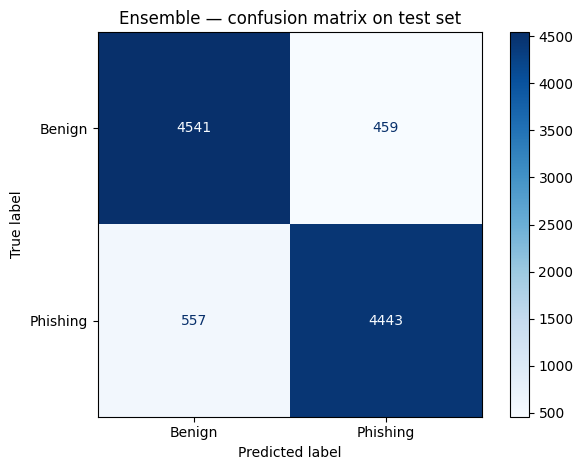

In [9]:
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Benign', 'Phishing'])
disp.plot(cmap='Blues')
plt.title('Ensemble — confusion matrix on test set')
plt.tight_layout()
plt.show()

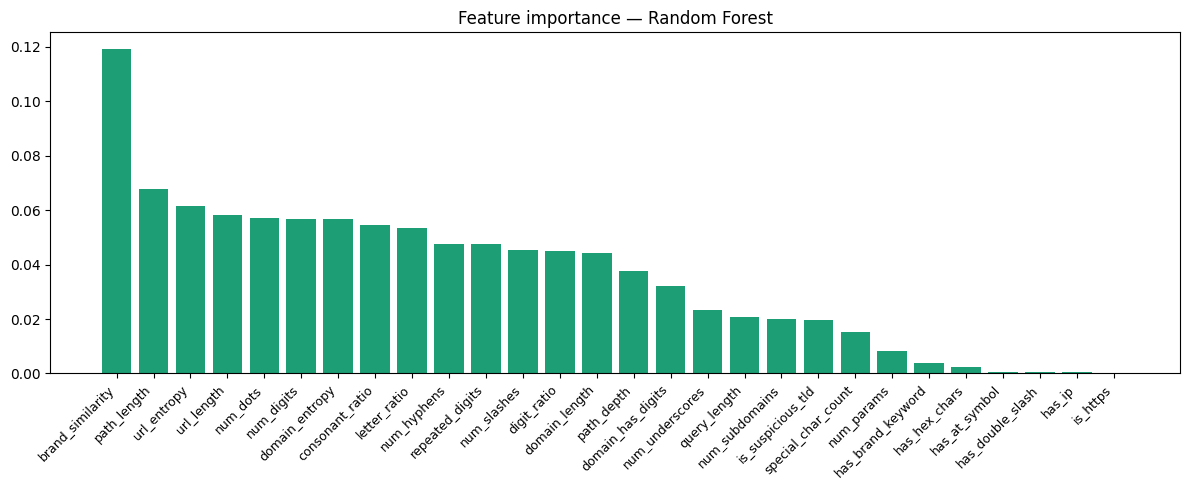


Top 5 most important features:
  brand_similarity: 0.1194
  path_length: 0.0679
  url_entropy: 0.0615
  url_length: 0.0583
  num_dots: 0.0572


In [10]:
feature_names = X.columns.tolist()
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 5))
plt.bar(range(len(feature_names)),
        importances[indices], color='#1D9E75', edgecolor='none')
plt.xticks(range(len(feature_names)),
           [feature_names[i] for i in indices],
           rotation=45, ha='right', fontsize=9)
plt.title('Feature importance — Random Forest')
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
for i in range(5):
    print(f"  {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

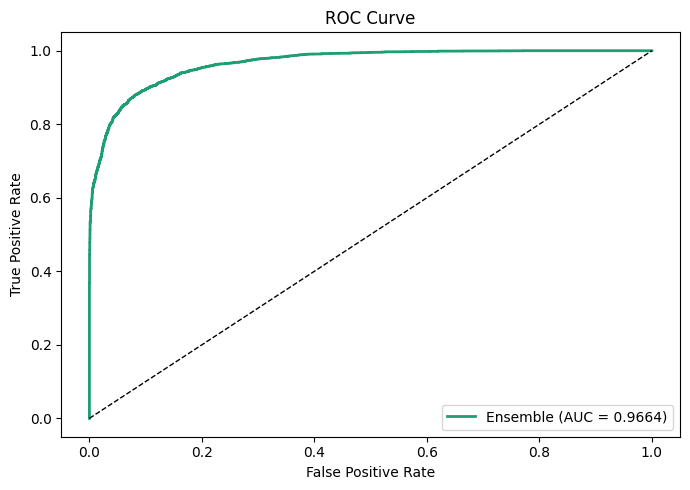

In [11]:
fpr, tpr, _ = roc_curve(y_test, test_probs)
auc = roc_auc_score(y_test, test_probs)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#1D9E75', linewidth=2,
         label=f'Ensemble (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
os.makedirs('../models', exist_ok=True)
joblib.dump(ensemble, '../models/ensemble_v1.pkl')
joblib.dump(list(X.columns), '../models/feature_names.pkl')
print("Saved:")
print("  models/ensemble_v1.pkl")
print("  models/feature_names.pkl")
print(f"\nFeature count: {len(X.columns)}")
print(f"Features: {list(X.columns)}")

Saved:
  models/ensemble_v1.pkl
  models/feature_names.pkl

Feature count: 28
Features: ['url_length', 'domain_length', 'path_length', 'num_dots', 'num_hyphens', 'num_underscores', 'num_slashes', 'num_digits', 'num_subdomains', 'path_depth', 'has_ip', 'has_at_symbol', 'has_double_slash', 'is_https', 'is_suspicious_tld', 'url_entropy', 'domain_entropy', 'has_brand_keyword', 'digit_ratio', 'letter_ratio', 'query_length', 'num_params', 'has_hex_chars', 'consonant_ratio', 'domain_has_digits', 'brand_similarity', 'special_char_count', 'repeated_digits']


In [13]:
from xgboost import XGBClassifier
import joblib
import os

print("Training lightweight XGBoost...")
xgb_light = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_light.fit(X_train, y_train)

# evaluate
from sklearn.metrics import accuracy_score
preds = xgb_light.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, preds)*100:.2f}%")

# save lightweight model
joblib.dump(xgb_light, '../models/model_light.pkl', compress=3)
joblib.dump(list(X_train.columns), '../models/feature_names.pkl')

size = os.path.getsize('../models/model_light.pkl') / (1024*1024)
print(f"Model size: {size:.1f} MB")

Training lightweight XGBoost...
Accuracy: 86.69%
Model size: 0.1 MB
